In [11]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
def plot_bar_chart(df, x, hue, title, facet=None, stacked_by=None):
    plt.figure(figsize=(10,6))
    
    if stacked_by:
        # group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                # add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            # add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # Regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage')
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)

            # add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage')
            plt.tight_layout()
            plt.show()

In [13]:
# Load the Parquet file
df = pq.read_table('../../data/healthcare-access/can_healthcare_access.parquet').to_pandas()

In [14]:
# display df
df.head()

,ref_date,geo,gender,unit,unmet_healthcare_needs,location,age
0,2018,Canada,Both sexes,Number_Thousands,1536.0,Canada,None
1,2018,Canada,Both sexes,Percent,5.1,Canada,None
2,2018,Canada,Males,Number_Thousands,683.0,Canada,None
3,2018,Canada,Males,Percent,4.6,Canada,None
4,2018,Canada,Females,Number_Thousands,853.0,Canada,None


In [15]:
df['ref_date'].unique()

array([2018, 2019, 2020, 2021, 2022, 2023])

In [16]:
# rename columns for easier access
df = df.rename(columns={'value':'unmet_healthcare_needs'})

# Extract Percentages and Counts

In [17]:
percentages = df[df['unit'] == 'Percent']
counts = df[df['unit'] == 'Number_Thousands']

# Distribution of unmet healthcare needs

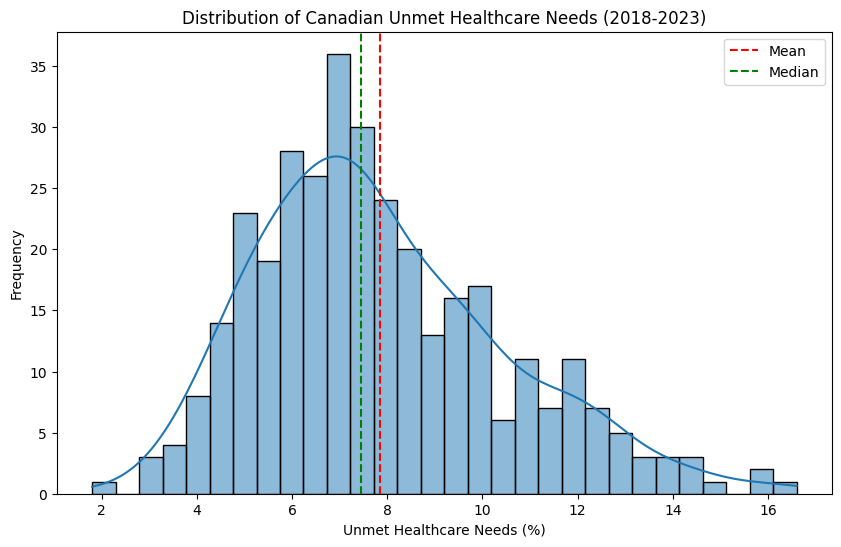

In [18]:
# plot distribution of unmet healthcare needs
plt.figure(figsize=(10, 6))
sns.histplot(percentages['unmet_healthcare_needs'], bins=30, kde=True)
plt.title('Distribution of Canadian Unmet Healthcare Needs (2018-2023)')
plt.xlabel('Unmet Healthcare Needs (%)')
plt.ylabel('Frequency')
plt.axvline(percentages['unmet_healthcare_needs'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(percentages['unmet_healthcare_needs'].median(), color='green', linestyle='--', label='Median')

plt.legend()
plt.show()


# Extract Percentage and Count of Unmet Healthcare Needs

In [19]:
percentages = df[df['unit'] == 'Percent']
counts = df[df['unit'] == 'Number_Thousands']

print("Percentages DataFrame:", percentages.shape[0])
print("Counts DataFrame:", counts.shape[0])
print(df.shape[0])

Percentages DataFrame: 342
Counts DataFrame: 341
683


# Unmet Healthcare Needs by Gender

## Percentage

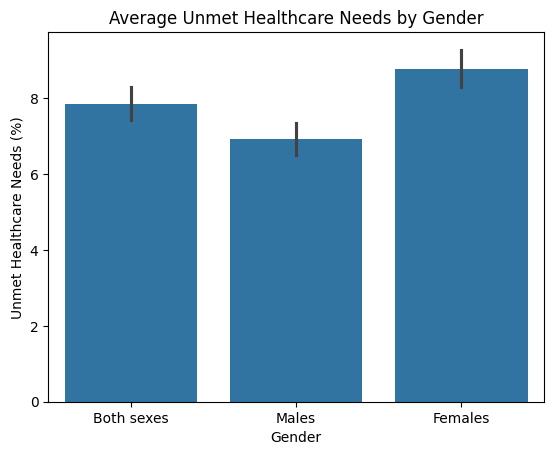

In [20]:
ax = sns.barplot(x='gender', y='unmet_healthcare_needs', data=percentages, estimator='mean')
ax.set_title('Average Unmet Healthcare Needs by Gender')
ax.set_ylabel('Unmet Healthcare Needs (%)')
ax.set_xlabel('Gender')
plt.show()

## Counts

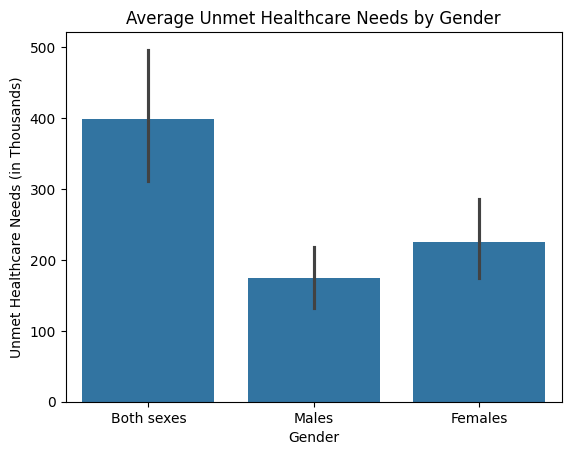

In [21]:
ax = sns.barplot(x='gender', y='unmet_healthcare_needs', data=counts, estimator='mean')
ax.set_title('Average Unmet Healthcare Needs by Gender')
ax.set_ylabel('Unmet Healthcare Needs (in Thousands)')
ax.set_xlabel('Gender')
plt.show()

# Unmet Healthcare Needs by Age Group

## Percentage

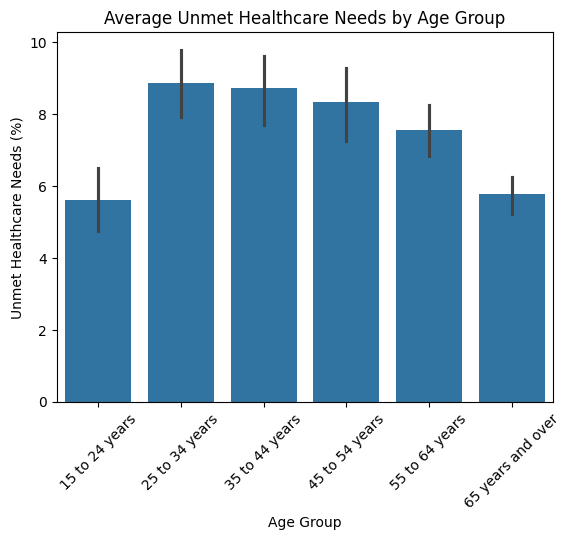

In [22]:
ax = sns.barplot(x='age', y='unmet_healthcare_needs', data=percentages, estimator='mean')
ax.set_title('Average Unmet Healthcare Needs by Age Group')
ax.set_ylabel('Unmet Healthcare Needs (%)')
ax.set_xlabel('Age Group')
# rotate x labels
plt.xticks(rotation=45)
plt.show()

## Counts

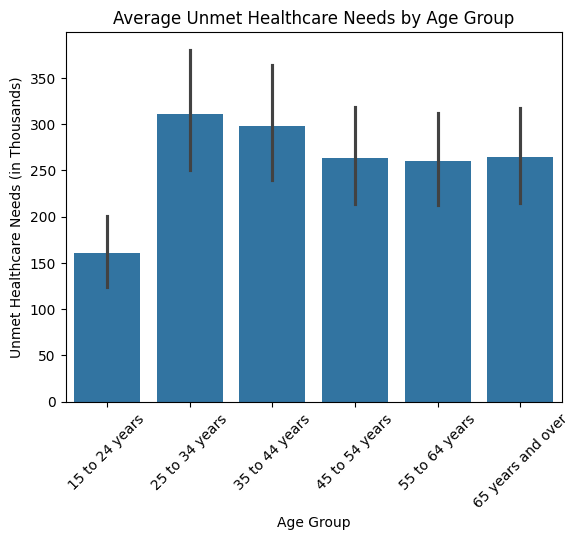

In [23]:
ax = sns.barplot(x='age', y='unmet_healthcare_needs', data=counts, estimator='mean')
ax.set_title('Average Unmet Healthcare Needs by Age Group')
ax.set_ylabel('Unmet Healthcare Needs (in Thousands)')
ax.set_xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

# Unmet Healthcare Needs by Location

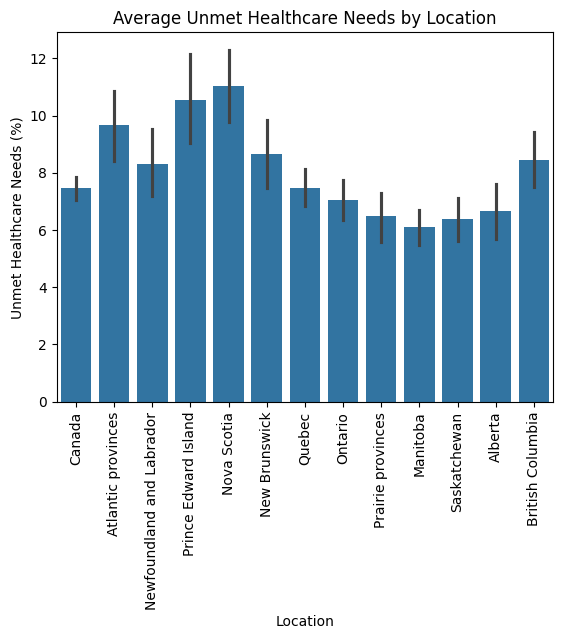

In [24]:
# Percentage
ax = sns.barplot(x='location', y='unmet_healthcare_needs', data=percentages, estimator='mean')
ax.set_title('Average Unmet Healthcare Needs by Location')
ax.set_ylabel('Unmet Healthcare Needs (%)')
ax.set_xlabel('Location')
# rotate x labels
plt.xticks(rotation=90)
plt.show()

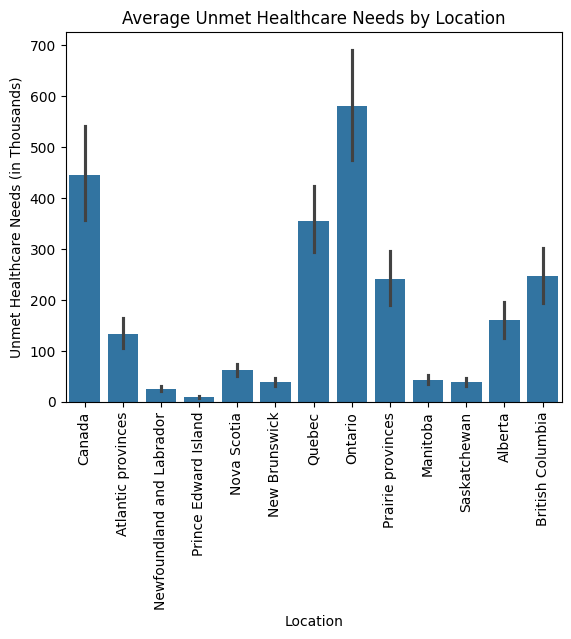

In [25]:
# Count
ax = sns.barplot(x='location', y='unmet_healthcare_needs', data=counts, estimator='mean')
ax.set_title('Average Unmet Healthcare Needs by Location')
ax.set_ylabel('Unmet Healthcare Needs (in Thousands)')
ax.set_xlabel('Location')
plt.xticks(rotation=90)
plt.show()

In [26]:
print(df['location'].unique())
df['geo'].unique()

['Canada' 'Atlantic provinces' 'Newfoundland and Labrador'
 'Prince Edward Island' 'Nova Scotia' 'New Brunswick' 'Quebec' 'Ontario'
 'Prairie provinces' 'Manitoba' 'Saskatchewan' 'Alberta'
 'British Columbia']


array(['Canada', 'Atlantic provinces', 'Newfoundland and Labrador',
       'Prince Edward Island', 'Nova Scotia', 'New Brunswick', 'Quebec',
       'Ontario', 'Prairie provinces', 'Manitoba', 'Saskatchewan',
       'Alberta', 'British Columbia', 'Canada, 15 to 24 years',
       'Canada, 25 to 34 years', 'Canada, 35 to 44 years',
       'Canada, 45 to 54 years', 'Canada, 55 to 64 years',
       'Canada,  65 years and over'], dtype=object)